In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [2]:
df=pd.read_csv('EV_Predictive_Maintenance_Dataset_15min.csv')

In [3]:
df.head()

,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [4]:
df.isna().sum()

Timestamp                 0
SoC                       0
SoH                       0
Battery_Voltage           0
Battery_Current           0
Battery_Temperature       0
Charge_Cycles             0
Motor_Temperature         0
Motor_Vibration           0
Motor_Torque              0
Motor_RPM                 0
Power_Consumption         0
Brake_Pad_Wear            0
Brake_Pressure            0
Reg_Brake_Efficiency      0
Tire_Pressure             0
Tire_Temperature          0
Suspension_Load           0
Ambient_Temperature       0
Ambient_Humidity          0
Load_Weight               0
Driving_Speed             0
Distance_Traveled         0
Idle_Time                 0
Route_Roughness           0
RUL                       0
Failure_Probability       0
Maintenance_Type          0
TTF                       0
Component_Health_Score    0
dtype: int64

In [5]:
df['RUL']

0         260.503381
1         212.813954
2         273.394511
3         229.508442
4         257.302631
             ...    
175388    252.165475
175389    230.284883
175390    242.494039
175391    262.523879
175392    294.147392
Name: RUL, Length: 175393, dtype: float64

<Axes: xlabel='RUL'>

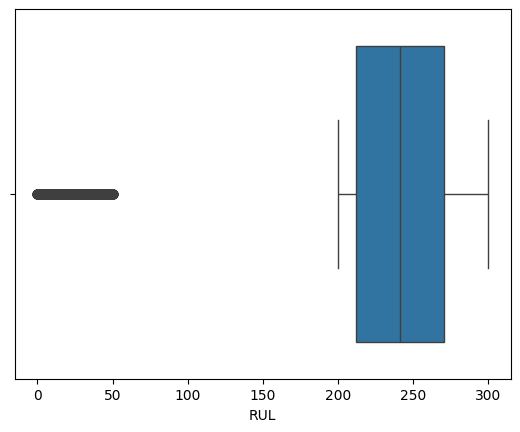

In [6]:
sns.boxplot(x=df['RUL'])

<Axes: xlabel='RUL', ylabel='Battery_Voltage'>

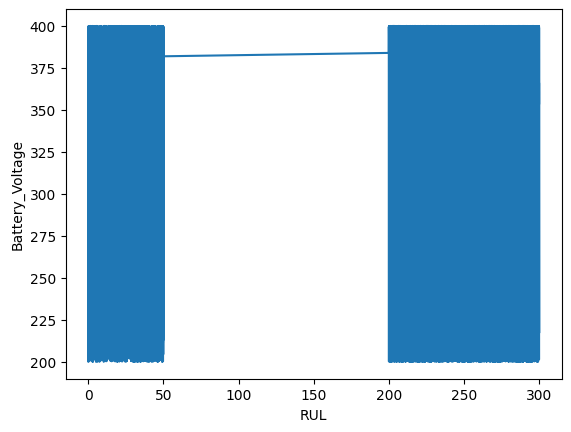

In [7]:
sns.lineplot(x=df['RUL'],y=df['Battery_Voltage'])

<Axes: xlabel='RUL', ylabel='Battery_Voltage'>

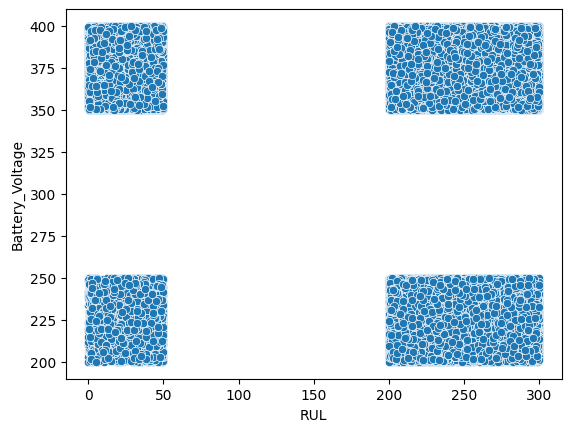

In [8]:
sns.scatterplot(x=df['RUL'],y=df['Battery_Voltage'])

In [9]:
df['Is_Unstable'] = (df['RUL'] <= 50).astype(int)

In [10]:
df['Is_Unstable'].value_counts()

Is_Unstable
0    149233
1     26160
Name: count, dtype: int64

<Axes: xlabel='Distance_Traveled', ylabel='Battery_Voltage'>

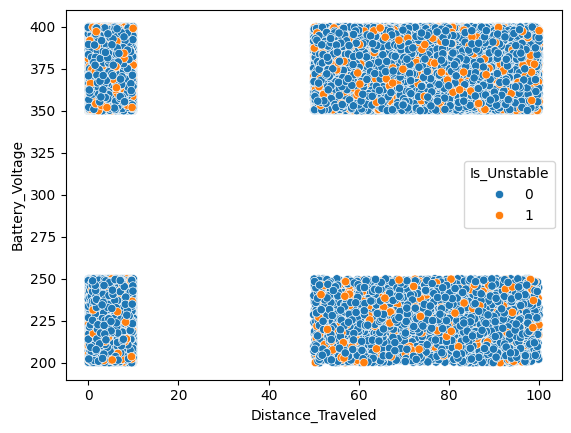

In [11]:
sns.scatterplot(df,x='Distance_Traveled',y='Battery_Voltage',hue='Is_Unstable')

<Axes: xlabel='Distance_Traveled', ylabel='Battery_Voltage'>

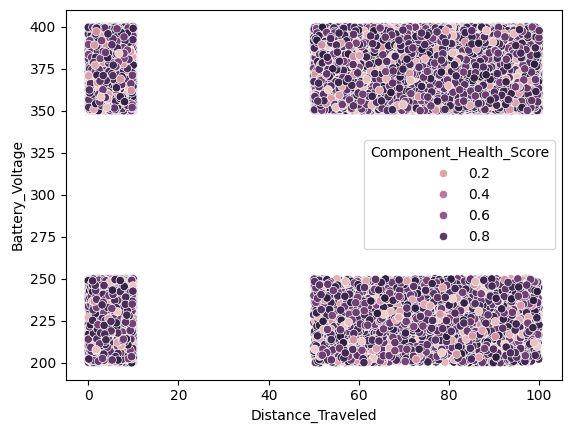

In [13]:
sns.scatterplot(df,x='Distance_Traveled',y='Battery_Voltage',hue='Component_Health_Score')

<Axes: xlabel='SoC', ylabel='RUL'>

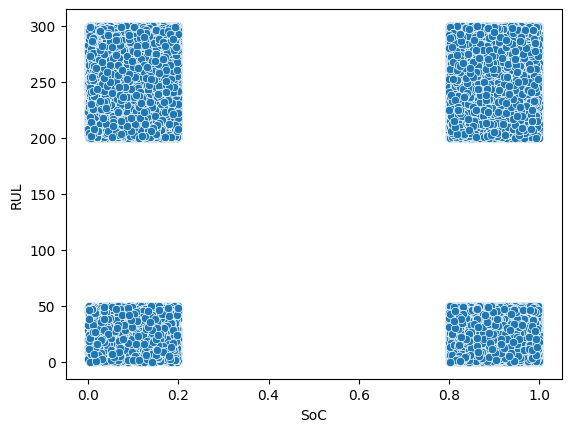

In [19]:
sns.scatterplot(x=df['SoC'],y=df['RUL'])

<Axes: xlabel='SoC', ylabel='Component_Health_Score'>

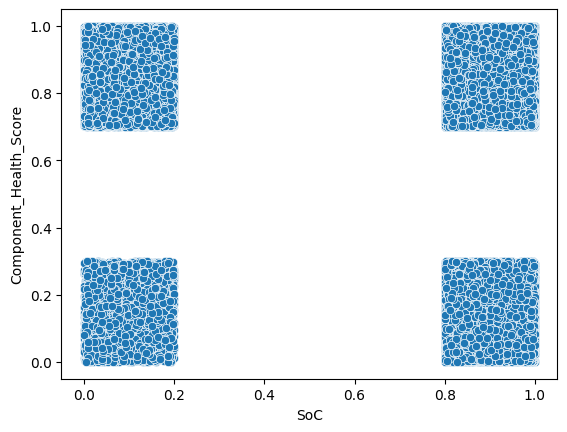

In [20]:
sns.scatterplot(x=df['SoC'],y=df['Component_Health_Score'])

<Axes: ylabel='SoC'>

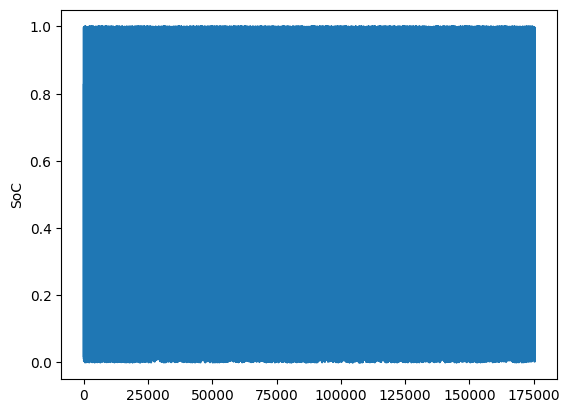

In [21]:
sns.lineplot(df['SoC'])

In [27]:
df['Failure_Probability'].unique()

array([0, 1])

C:\Users\Shaeel\AppData\Local\Temp\ipykernel_8716\2906184200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Failure_Probability', y='Battery_Current', data=df, palette='Set2')


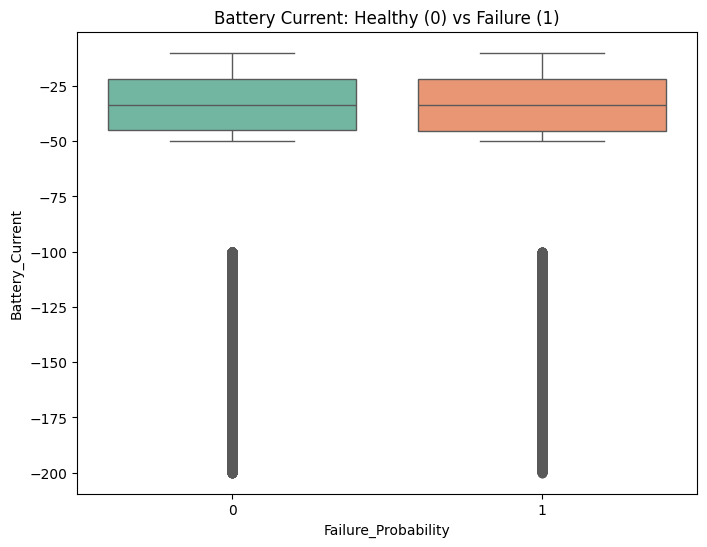

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Failure_Probability', y='Battery_Current', data=df, palette='Set2')
plt.title('Battery Current: Healthy (0) vs Failure (1)')
plt.show()

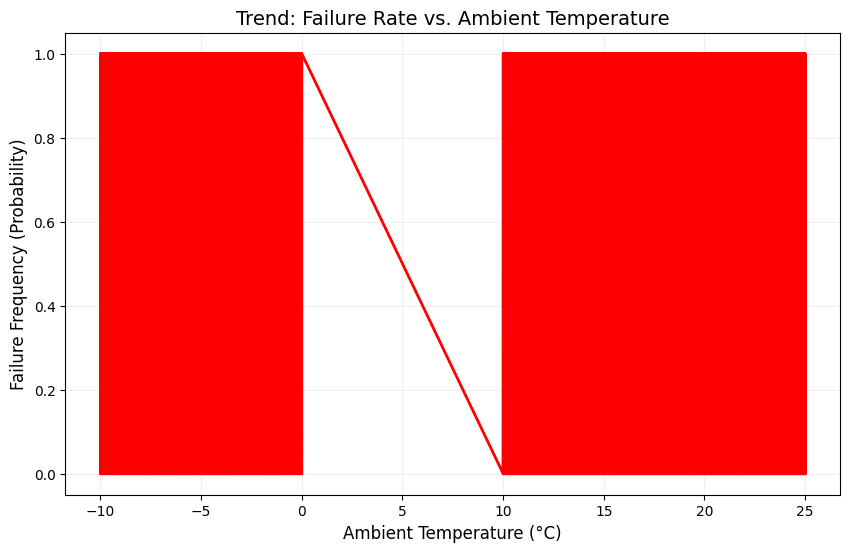

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Seaborn's lineplot is smart: it will automatically calculate the MEAN 
# of your 0s and 1s for every temperature. This mean = Probability.
sns.lineplot(data=df, x='Ambient_Temperature', y='Failure_Probability', color='red', linewidth=2)

plt.title('Trend: Failure Rate vs. Ambient Temperature', fontsize=14)
plt.xlabel('Ambient Temperature (°C)', fontsize=12)
plt.ylabel('Failure Frequency (Probability)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

<Axes: xlabel='SoC', ylabel='Charge_Cycles'>

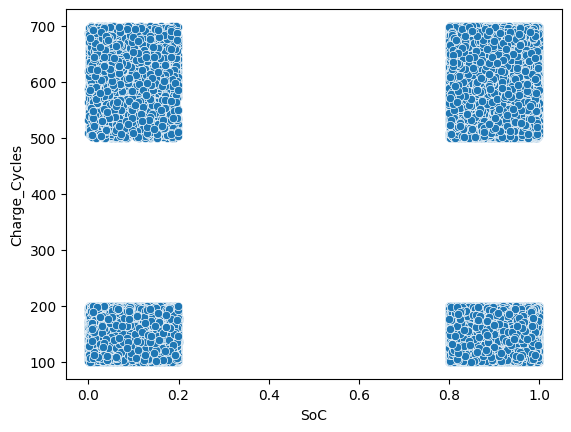

In [18]:
sns.scatterplot(x=df['SoC'],y=df['Charge_Cycles'])

In [17]:
# Group by the boxes to see if the average RUL is different
df['Voltage_Group'] = pd.cut(df['Battery_Voltage'], bins=[0, 300, 500], labels=['Low', 'High'])
df['Cycle_Group'] = pd.cut(df['Charge_Cycles'], bins=[0, 300, 800], labels=['Low', 'High'])

print(df.groupby(['Voltage_Group', 'Cycle_Group'])['RUL'].mean())

Voltage_Group  Cycle_Group
Low            Low            215.933799
               High           216.621837
High           Low            216.236829
               High           217.481176
Name: RUL, dtype: float64


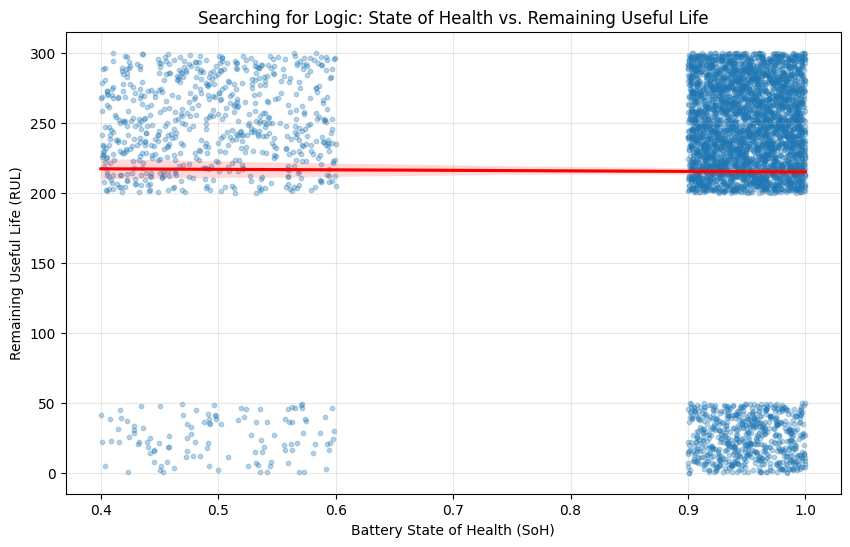

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# We take a sample of 5000 rows so the graph doesn't turn into a 'solid block'
# regplot will draw a 'Trend Line' (Regression Line) automatically.
plt.figure(figsize=(10,6))
sns.regplot(data=df.sample(5000), x='SoH', y='RUL', 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.title('Searching for Logic: State of Health vs. Remaining Useful Life')
plt.xlabel('Battery State of Health (SoH)')
plt.ylabel('Remaining Useful Life (RUL)')
plt.grid(True, alpha=0.3)
plt.show()

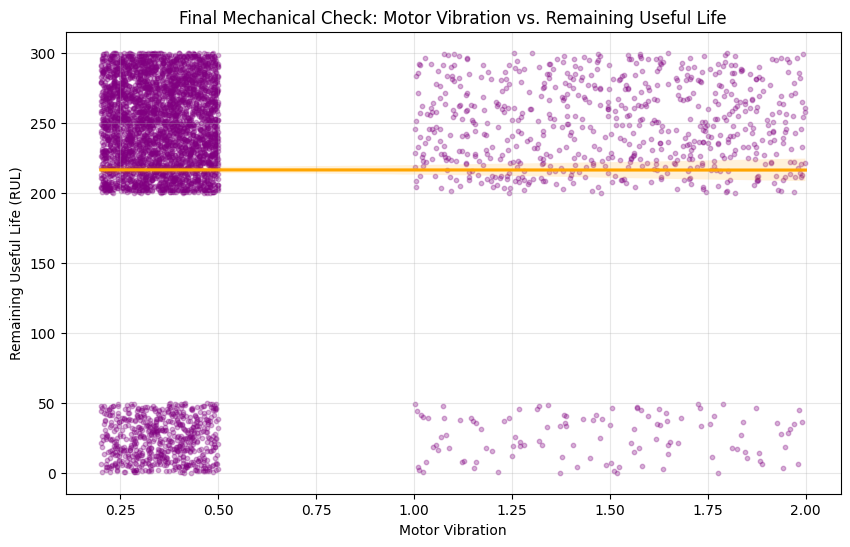

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Sampling to avoid the "blue block"
sns.regplot(data=df.sample(5000), x='Motor_Vibration', y='RUL', 
            scatter_kws={'alpha':0.3, 's':10, 'color':'purple'}, line_kws={'color':'orange'})

plt.title('Final Mechanical Check: Motor Vibration vs. Remaining Useful Life')
plt.xlabel('Motor Vibration')
plt.ylabel('Remaining Useful Life (RUL)')
plt.grid(True, alpha=0.3)
plt.show()